In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_excel('D:/Python/Scores.xlsx')

In [3]:
X_train=data.iloc[:,:-1].values
y_train=data.iloc[:,-1].values
print(X_train[:5])
print(y_train[:5])

[[30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]
 [45.08327748 56.31637178]]
[0 0 1 1 0]


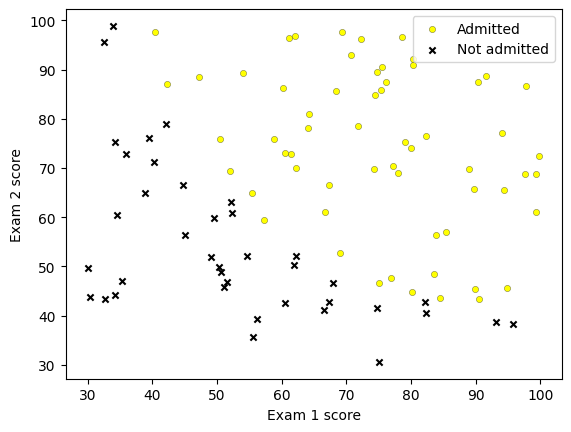

In [4]:
plt.scatter(X_train[y_train==1][:,0],X_train[y_train==1][:,1],color='yellow',marker='o',edgecolors='black',linewidth=0.2,s=20,label='Admitted')
plt.scatter(X_train[y_train==0][:,0],X_train[y_train==0][:,1],color='black',marker='x',s=20,label='Not admitted')  
plt.ylabel('Exam 2 score') 
plt.xlabel('Exam 1 score') 
plt.legend(loc="upper right")
plt.show()

In [5]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [6]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0
    for i in range(m):
        z=np.dot(w,X[i])+b
        g=sigmoid(z)
        epsilon = 1e-15
        g = np.clip(g, epsilon, 1 - epsilon)
        cost+=-y[i]*np.log(g)-(1-y[i])*np.log(1-g)
    return cost/m

In [7]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    dw=np.zeros(n)
    db=0
    for i in range(m):
        z=np.dot(w,X[i])+b
        g=sigmoid(z)
        error=g-y[i]
        dw+=error*X[i]
        db+=error
    dw/=m
    db/=m
    return dw,db

In [8]:
def gradient_descent(X,y,w_init,b_init,alpha,num_iters,compute_cost,compute_gradient):
    
    w=w_init
    b=b_init
    J_history=[]    
    for i in range(num_iters):
        z=np.dot(X,w)+b
        g=sigmoid(z)
        dJ_dw,dJ_db=compute_gradient(X,y,w,b)
        w-=alpha*dJ_dw
        b-=alpha*dJ_db
        cost=compute_cost(X,y,w,b)
        if i%1000==0:
            print(f"Iteration {i}: Cost {cost}")    
        J_history.append(cost)
    return w,b,J_history

Iteration 0: Cost 0.9872920419787032
Iteration 1000: Cost 0.30379196046334306
Iteration 2000: Cost 0.30343234963365484
Iteration 3000: Cost 0.3030750980787154
Iteration 4000: Cost 0.3027201824357201
Optimized weights: [0.06951113 0.06541381], bias: -8.093592576146376


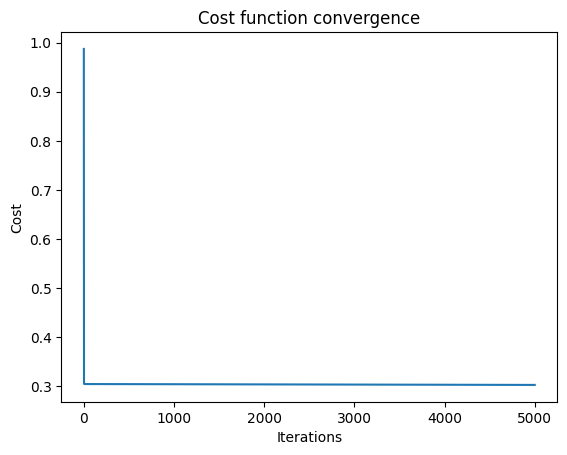

In [9]:
W_ini=np.zeros(X_train.shape[1])
b_init=-8
alpha=0.001  
num_iters=5000
w,b,J_history=gradient_descent(X_train,y_train,W_ini,b_init,alpha,num_iters,compute_cost,compute_gradient)
print(f"Optimized weights: {w}, bias: {b}")
plt.plot(J_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost function convergence')
plt.show()


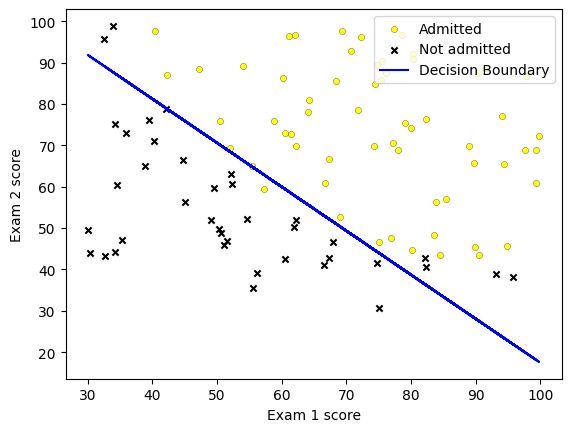

In [10]:
plt.scatter(X_train[y_train==1][:,0],X_train[y_train==1][:,1],color='yellow',marker='o',edgecolors='black',linewidth=0.2,s=20,label='Admitted')
plt.scatter(X_train[y_train==0][:,0],X_train[y_train==0][:,1],color='black',marker='x',s=20,label='Not admitted') 
plt.plot(X_train[:,0],-(w[0]*X_train[:,0]+b)/w[1],color='blue',label='Decision Boundary')
plt.ylabel('Exam 2 score')  
plt.xlabel('Exam 1 score')
plt.legend(loc="upper right")
plt.show()
